---
# <div style="text-align: center"> Introduction </div>
---

Along these tutorials, we will see how <span style="color:blue">**SCOPE**</span> interacts with the different parts of the code to handle the execution of computational workflows. 

These are the topics covered in each tutorial:
1) The **System** class and its sources: the **Specie**, **Cell** and **Atom** classes  
2) The Computational workflow: **Branch**, **Workflow**, **Job**, and **Computation** classes  
3) The **State** class  
4) The **Data**, **Collection** and **VNM** classes
5) The **Input_data** class, and **scope input files**
6) Running <span style="color:blue">**SCOPE**</span> - Part 1: File Structure
7) Running <span style="color:blue">**SCOPE**</span> - Part 2: Execution 
8) Running <span style="color:blue">**SCOPE**</span> - Part 3: Detailed Actions

---
# <div style="text-align: center"> Tutorial 4: Data, Collection and VNM Classes</div>
---

In this tutorial, we will compute the thermodynamic properties for the "b3lpy_opt" **State** that we found in Tutorial 3, which includes the vibrational normal modes of a molecule. While doing so:
- we will discuss the **Data** and **Collection** classes, which are used in SCOPE to interact with -and store- results
- we will discuss the **VNM** class (VNM = Vibrational Normal Mode), which is currently the only quantum-chemistry-oriented class implemented in SCOPE

In [1]:
import os
import scope
import numpy as np

In [2]:
## Path of the data folder. It should be "os.path.abspath('.')+'/Data"
data_folder = os.path.abspath('../')+'/Data/1-Tutorial_1/'
## Loads the System object from a binary file, provided in the tutorial folder
sys = scope.load_binary(f"{data_folder}ABITEM.npy")

In [3]:
## Then, we select the source 
found, source = sys.find_source("ref_hs_mol")

## And the state
found, final_state = source.find_state("b3lyp_opt")
print(final_state)

---------------------------------------------------
   STATE                                           
---------------------------------------------------
 Name                  = b3lyp_opt
 Source Name           = ref_hs_mol
 Source Type           = specie
 Labels                = Fe...
 Coord                 = [3.774774, 3.779086, 13.494815]...
 Is Minimum            = True
 # Molecules:          = 1
 With Formulae:                               
    0: H18-C20-N6-S2-Fe 



## Vibrational Normal Modes (VNMs)

In [4]:
## Notice that the state is a minimum energy structure:
print(final_state.isminimum)

True


In [5]:
## This is because the user provided the VNM. Here's the first one
print(final_state.VNMs[0])

-----------------------------
   Vibrational Normal Mode   
-----------------------------
 Index                  = 1
 Freq (cm-1)            = 21.6469
 IR Intensity (KM/Mole) = 1.0847
 Reduced Mass (AMU)     = 14.2624
 Has Mode               = False



In [6]:
# By default, the eigenvectors of the VNMs are not stored... 
print(final_state.VNMs[0].has_mode)

False


In [7]:
# ... but they can be parsed if needed. To do it:
freq_comp = final_state.computations[-1]                                       ## Select the computation
freq_comp.out_path = f"{data_folder}ABITEM_ref_hs_mol_freq_r1.log"             ## Modify is original path to re-read it

# And parse the frequencies
from scope.register_data import reg_frequencies
worked = reg_frequencies(freq_comp, witheigen=True)
print(final_state.VNMs[0].has_mode)

True


## Thermodynamic Properties

### Data Structure: Data and Collection

In [8]:
# Because the state contains the VNMs, we can compute the Thermodynamic Properties:
final_state.get_thermal_data(overwrite=True)


In [9]:
# The above function computes the vibrational enthalpy (Hvib) and entropy (Svib), as defined in the manuscript. 
# These, together with the electronic enthalpy (Helec) and entropy (Selec) are used to compute the Gibbs Free Energy (Gtot)
print(final_state.results["Helec"])   
print(final_state.results["Selec"])   


Helec: -3159.62579289 au
Selec:   0.00000510 au


In [10]:
# The DATA class forces the results to be stored together with the units, and the function where they're computed.
print(final_state.results["Helec"].value)
print(final_state.results["Helec"].units)
print(final_state.results["Helec"].function)

-3159.62579289
au
state.get_thermal_data()


In [11]:
# Notice that Helec and Selec are just a single instance of a so called DATA-class.
final_state.results["Helec"].type

'data'

In [12]:
# In turn, Hvib, Svib and Gtot are a so-called COLLECTION class. This class gathers several data entries into a single instance 
print(final_state.results["Hvib"])
print(final_state.results["Svib"])
print(final_state.results["Gtot"])

---------------------------------------------------
   COLLECTION OF DATA   = Hvib                
---------------------------------------------------
 Variable              = Temperature
 #Entries              = 491
 First                 = 0.35192142594527903
 Last                  = 0.41498711454900233
 Units                 = au
 Function              = scope.thermal_corrections.get_Hvib()

---------------------------------------------------
   COLLECTION OF DATA   = Svib                
---------------------------------------------------
 Variable              = Temperature
 #Entries              = 491
 First                 = 1.346720714505055e-06
 Last                  = 0.00026509997016783504
 Units                 = au
 Function              = scope.thermal_corrections.get_Svib()

---------------------------------------------------
   COLLECTION OF DATA   = Gtot                
---------------------------------------------------
 Variable              = Temperature
 #Entries  

In [13]:
# Again, units and the used function are specified:
print(final_state.results["Hvib"].units)
print(final_state.results["Hvib"].function)
# Also, what is the variable that changes within the collection:
print(final_state.results["Hvib"].variable)

au
scope.thermal_corrections.get_Hvib()
Temperature


In [14]:
# To retrieve the values out of a COLLECTION class, you can:
print(final_state.results["Hvib"].get_values()[0:10]) # Notice that only the first 10 entries are printed


[0.35192143 0.35192619 0.35193192 0.35193862 0.35194627 0.35195484
 0.35196433 0.35197471 0.35198596 0.35199809]


In [15]:
# To access an individual entry, you can search by the name of variable, and its value
final_state.results["Hvib"].find_value_with_property("temperature", 200)

Hvib:   0.36348555 au

### Subtracting and Plotting Collections

In [16]:
# Collections can be subtracted:
HS_state = final_state # we were operating with the HS molecule's data

## Lets select the LS as well, and compute its TD properties 
found, source   = sys.find_source("ref_ls_mol")
found, LS_state = source.find_state("b3lyp_opt")
LS_state.get_thermal_data()

print(HS_state)
print(LS_state)

---------------------------------------------------
   STATE                                           
---------------------------------------------------
 Name                  = b3lyp_opt
 Source Name           = ref_hs_mol
 Source Type           = specie
 Labels                = Fe...
 Coord                 = [3.774774, 3.779086, 13.494815]...
 Number of Complexes   = 1
 Is Minimum            = True
 # Molecules:          = 1
 With Formulae:                               
    0: H18-C20-N6-S2-Fe 

---------------------------------------------------
   STATE                                           
---------------------------------------------------
 Name                  = b3lyp_opt
 Source Name           = ref_ls_mol
 Source Type           = specie
 Labels                = Fe...
 Coord                 = [4.171778, 7.781139, 4.158969]...
 Number of Complexes   = 1
 Is Minimum            = True
 # Molecules:          = 1
 With Formulae:                               
    0: H18-C2

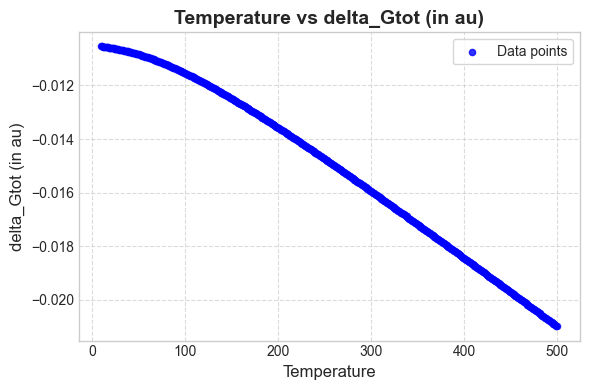

In [17]:
# Collections to substract
HS_Gtot = HS_state.results["Gtot"]
LS_Gtot = LS_state.results["Gtot"]

# New collection:
dGtot = HS_Gtot - LS_Gtot

# There is a simple function to plot Collections 
dGtot.plot()

### Actual Values (Accuracy)

In [18]:
## Above, we have seen how the computed thermochemistry values are handled by SCOPE. Now, we have a look at the actual values

In [19]:
## Helec, is just the "SCF Done" energy in Gaussian16:
lines       = scope.parse_general.read_lines_file(freq_comp.out_path)           ## Here we just read the lines of the output file...
line, found = scope.parse_general.search_string("SCF Done", lines, typ='last')  ## Search for SCF Done
print(lines[line].strip())                                                      ## And print it
print(final_state.results["Helec"])                                             ## For comparison

## Selec, is obtained as R·ln(2S+1), so:
print(f"Selec: {scope.constants.R_J*np.log(final_state.spin_multiplicity)/scope.constants.har2kJmol/1000:.8f} au")  ## Here we compute Selec from the State's spin multiplicity
print(final_state.results["Selec"])                                                                                 ## For comparison

SCF Done:  E(UB3LYP) =  -3159.62579289     A.U. after   39 cycles
Helec: -3159.62579289 au
Selec: 0.00000510 au
Selec:   0.00000510 au


In [20]:
## Hvib is computed by the get_Hvib function. Here, we do it at 298.15 to be able to compare with the Gaussian16 output. 
hvib = scope.thermal_corrections.get_Hvib(final_state.freqs_cm, temp=298.15, freq_units='cm')
print(hvib)

## Value in G16:
line, found = scope.parse_general.search_string("Thermal correction to Energy", lines, typ='last') 
print(lines[line].strip())                                                      

## The difference between the two terms (0.378882 vs. 0.3760) corresponds to the rotational and translational energy, which are not included in our computed Hvib 

Hvib:   0.37604956 au
Thermal correction to Energy=                    0.378882


In [21]:
## In debug mode, you can compare the contributions of each VNM, with the value in Gaussian16 output file:
scope.thermal_corrections.get_Hvib(final_state.freqs_cm, temp=298.15, freq_units='cm', debug=1)

GET_Hvib: Computing Hvib with 135 frequencies, and first: 21.6469 cm
	0 i= 21.65 cm-1: Hvib(i)= 9.4505e-04 a.u, Hvib(i)= 0.5930 kcal/mol
	1 i= 28.41 cm-1: Hvib(i)= 9.4567e-04 a.u, Hvib(i)= 0.5934 kcal/mol
	2 i= 29.16 cm-1: Hvib(i)= 9.4575e-04 a.u, Hvib(i)= 0.5935 kcal/mol
	3 i= 34.17 cm-1: Hvib(i)= 9.4633e-04 a.u, Hvib(i)= 0.5938 kcal/mol
	4 i= 39.76 cm-1: Hvib(i)= 9.4708e-04 a.u, Hvib(i)= 0.5943 kcal/mol
	5 i= 57.09 cm-1: Hvib(i)= 9.5015e-04 a.u, Hvib(i)= 0.5962 kcal/mol
	6 i= 70.07 cm-1: Hvib(i)= 9.5317e-04 a.u, Hvib(i)= 0.5981 kcal/mol
	7 i= 74.84 cm-1: Hvib(i)= 9.5443e-04 a.u, Hvib(i)= 0.5989 kcal/mol
	8 i= 80.77 cm-1: Hvib(i)= 9.5611e-04 a.u, Hvib(i)= 0.6000 kcal/mol
	9 i= 90.43 cm-1: Hvib(i)= 9.5913e-04 a.u, Hvib(i)= 0.6019 kcal/mol
	10 i= 94.48 cm-1: Hvib(i)= 9.6049e-04 a.u, Hvib(i)= 0.6027 kcal/mol
	11 i= 107.83 cm-1: Hvib(i)= 9.6540e-04 a.u, Hvib(i)= 0.6058 kcal/mol
	12 i= 123.19 cm-1: Hvib(i)= 9.7183e-04 a.u, Hvib(i)= 0.6098 kcal/mol
	13 i= 137.79 cm-1: Hvib(i)= 9.7872e-04 a.

Hvib:   0.37604956 au

In [22]:
## You can see above that, for i=21.65, corresponding to VNM number 1, Hvib(i) is 0.5930 kcal/mol. 

## In the G16 output:
line, found = scope.parse_general.search_string("Vibration     1 ", lines, typ='last') 

## You can find this block, where you can see that Hvib(i) is the same 
print('                     ',lines[line-7].strip())
print('                     ',lines[line-6].strip())
print(lines[line].strip())

                      E (Thermal)             CV                S
                      KCal/Mol        Cal/Mol-Kelvin    Cal/Mol-Kelvin
Vibration     1          0.593              1.985              6.477


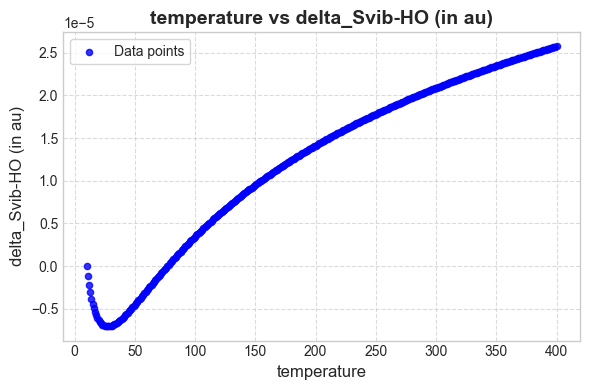

In [23]:
## For Svib, we implemented: 
    # - The default Harmonic-Oscillator (HO) model
    # - The Quasi-Rigid-Rotor-Harmonic-Oscillator (QRRHO) model by Grimme, as described in: Grimme, S. Chem. Eur. J., 2012, 18, 9955–9964. 

## It is possible to compare these methods:
vals1 = scope.classes_data.Collection('Svib-HO', 'temperature')
vals2 = scope.classes_data.Collection('Svib-QRRHO', 'temperature')
for t in range(10,401,1):
    vals1.add_data(scope.thermal_corrections.get_Svib(final_state.freqs_cm, temp=t, freq_units='cm'))
    vals2.add_data(scope.thermal_corrections.get_Svib(final_state.freqs_cm, temp=t, freq_units='cm', typ='qrrho'))

## The difference between those methods can be significant
(vals1 - vals2).plot()

In [24]:
## By default, the HO is employed. At 298.15 K:
val = scope.thermal_corrections.get_Svib(final_state.freqs_cm, temp=298.15, freq_units='cm')
print(val)

Svib:   0.00016716 au


In [25]:
## Summing the electronic entropy:
Stot = val.value + final_state.results["Selec"].value
## And multiplyhing by T 
Stot = Stot * 298.15
## We obtain:
print(f"{Stot:.6f}")

0.051359


In [26]:
## Together with hvib estimated above at 298.15 K:
Gtot = hvib.value-Stot 
print(f"{Gtot:.6f}")

0.324691


In [27]:
## The total thermal correction computed by Gaussian16 (ca. 0.290320 au)
line, found = scope.parse_general.search_string("Thermal correction to Gibbs", lines, typ='last') 
print(lines[line].strip())                                                     


Thermal correction to Gibbs Free Energy=         0.290320


In [ ]:
## The difference between those two approaches is that Gaussian16 includes, again, rotational and translational entropy. 

### Computation of T12 (SCO systems)

In [29]:
from scope_sco.sco_functions import get_T12

## For SCO systems, the transition temperature associated with the thermal spin transition LS->HS can be computed.

## The branch is the platform where the results will be stored
found, branch = sys.find_branch("Isolated")
## And the T12 is computed
worked, t12 = get_T12(branch, HS_state, LS_state, flexible=True)
print(worked)
print(t12)
# In this case, there is no T12, since the HS state is always more stable than the LS one. You can see in the dGtot plot above that dGtot is always negative

True
T12: None


## Units Conversion

In [30]:
## A very basic system to change units has been implemented at the DATA class level (not for collections).
print(final_state.results["Helec"])

## print_in_units() will preserve the original units:
print(final_state.results["Helec"].print_in_units("ev"))
print(final_state.results["Helec"])

## Convert to units function will overwrite the DATA units permanently:
print(final_state.results["Helec"].convert_to_units("cm"))
print(final_state.results["Helec"])

Helec: -3159.62579289 au
Helec: -85977.83814102 ev
Helec: -3159.62579289 au
Helec: -693457607.04421556 cm
Helec: -693457607.04421556 cm
